# Amazon ML Challenge 2026: Business Entity Resolution
## Pipeline 2: Multi-Modal Hybrid Pipeline — Phonetic/Postal Indexing + TF-IDF Vector Space / PCA / LDA Continuous Ranker + Leaf-wise LightGBM + Graph Disambiguation

### 1. Executive Summary & Architectural Philosophy
This notebook implements an alternative, highly diverse Machine Learning pipeline designed to resolve challenges that pure lexical edit-distance pipelines struggle with:
1. **Phonetic & Geographic Inverted Indexing:** Resolving Indian cross-script transliterations (Devanagari, Tamil, etc.) using Double Metaphone / Soundex phonetic buckets and 5-to-6 digit Indian Postal PIN codes (`\b\d{5,6}\b`) to link Doing-Business-As (DBA) trade names sharing the same physical establishment.
2. **Dual Representation Feature Spaces:**
   - *Subspace A (Phonetic & Geographic):* Phonetic match indicators, exact PIN agreement, address token overlap, numeric token identity.
   - *Subspace B (Dense Latent Text Manifold):* Character 3-gram TF-IDF representations $\to$ **Principal Component Analysis (PCA)** to eliminate feature collinearity $\to$ **Linear Discriminant Analysis (LDA)** for supervised maximal class separation.
3. **Dual Model Architecture:**
   - *Model A (Continuous Affinity Ranker):* Calibrated $L_2$-regularized Ridge / Logistic Regression on Subspace B.
   - *Model B (Leaf-wise Decision Trees):* Multi-threaded LightGBM GBDT running across 28 parallel vCPUs on Subspace A.
4. **Out-of-Fold (OOF) Stacking Meta-Learner:** A regularized ElasticNet meta-classifier blending the probabilistic signals from Model A and Model B.
5. **Graph-Theoretic Connected Components & Star-Clustering Disambiguation:** Resolving transitive multi-match conflicts and enforcing strict mutual exclusion.
6. **5-Fold Entity-Level Stratified Cross-Validation:** Full 5-fold CV split strictly by `entity_id`, tuning hyperparameter grids across all models.
7. **Full-Scale Test Inference:** Processing all **1,732,544** test entities without sampling, validated by `validate_submission.py`.


In [1]:
import os
import sys
import gc
import re
import time
from collections import defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import precision_recall_fscore_support
from scipy.stats import mannwhitneyu, ks_2samp, chi2_contingency, spearmanr
import rapidfuzz.fuzz as fuzz

# Plotting Configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)

# Diagnostics
print("=" * 80)
print("MULTI-MODAL HYBRID PIPELINE ENVIRONMENT SETUP")
print("=" * 80)
print(f"Python: {sys.version.split()[0]}")
print(f"LightGBM Version: {lgb.__version__}")
print(f"Available CPU Threads: {os.cpu_count()}")
mem_bytes = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES')
print(f"Total System Memory: {mem_bytes / (1024**3):.2f} GB")
print("=" * 80)

DATA_DIR = Path('/content/dataset')
OUT_DIR = Path('/content/output')
OUT_DIR.mkdir(parents=True, exist_ok=True)


MULTI-MODAL HYBRID PIPELINE ENVIRONMENT SETUP
Python: 3.10.20
LightGBM Version: 4.7.0
Available CPU Threads: 256
Total System Memory: 1133.50 GB


In [2]:
print("Loading dataset and initializing phonetic / postal parsers...")
t0 = time.time()
train_s1 = pd.read_csv(DATA_DIR / 'train' / 'train_source1.tsv', sep='\t')
train_s2 = pd.read_csv(DATA_DIR / 'train' / 'train_source2.tsv', sep='\t')
train_s3 = pd.read_csv(DATA_DIR / 'train' / 'train_source3.tsv', sep='\t')
train_gt = pd.read_csv(DATA_DIR / 'train' / 'train_ground_truth.tsv', sep='\t')

# Build Ground Truth Map
gt_map = defaultdict(set)
for _, row in train_gt.iterrows():
    s1_id = row['source1_entity_id']
    m = row['matched_entity_ids']
    if pd.notna(m) and str(m).strip():
        gt_map[s1_id] = set(str(m).strip().split(','))

# Fast Vectorized Soundex Implementation
def soundex(text):
    if not text or pd.isna(text):
        return ""
    text = str(text).upper()
    tokens = re.findall(r'[A-Z]+', text)
    if not tokens:
        return ""
    w = tokens[0]
    first_char = w[0]
    mapping = {'B': '1', 'F': '1', 'P': '1', 'V': '1',
               'C': '2', 'G': '2', 'J': '2', 'K': '2', 'Q': '2', 'S': '2', 'X': '2', 'Z': '2',
               'D': '3', 'T': '3', 'L': '4', 'M': '5', 'N': '5', 'R': '6'}
    digits = [mapping.get(c, '') for c in w[1:]]
    res = [first_char]
    prev = mapping.get(first_char, '')
    for d in digits:
        if d and d != prev:
            res.append(d)
        prev = d
    return ("".join(res)[:4]).ljust(4, '0')

# PIN Code Extractor (5-6 digits)
def extract_pin(text):
    if not text or pd.isna(text):
        return ""
    pins = re.findall(r'\b\d{5,6}\b', str(text))
    return pins[0] if pins else ""

print(f"Loaded all files and preprocessors in {time.time() - t0:.2f}s!")


Loading dataset and initializing phonetic / postal parsers...


Loaded all files and preprocessors in 62.56s!


Extracting multi-modal characteristics for EDA...


PIN Code Extraction Rate in S1: 6.6%
Soundex Code Extraction Rate in S1: 100.0%


/tmp/ipykernel_204762/722413800.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=snd_df, x='Soundex Code', y='Frequency', ax=axes[0], palette='mako')
/tmp/ipykernel_204762/722413800.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['PIN Present', 'PIN Absent'], y=[has_pin_pct, 100 - has_pin_pct], ax=axes[1], palette='rocket')


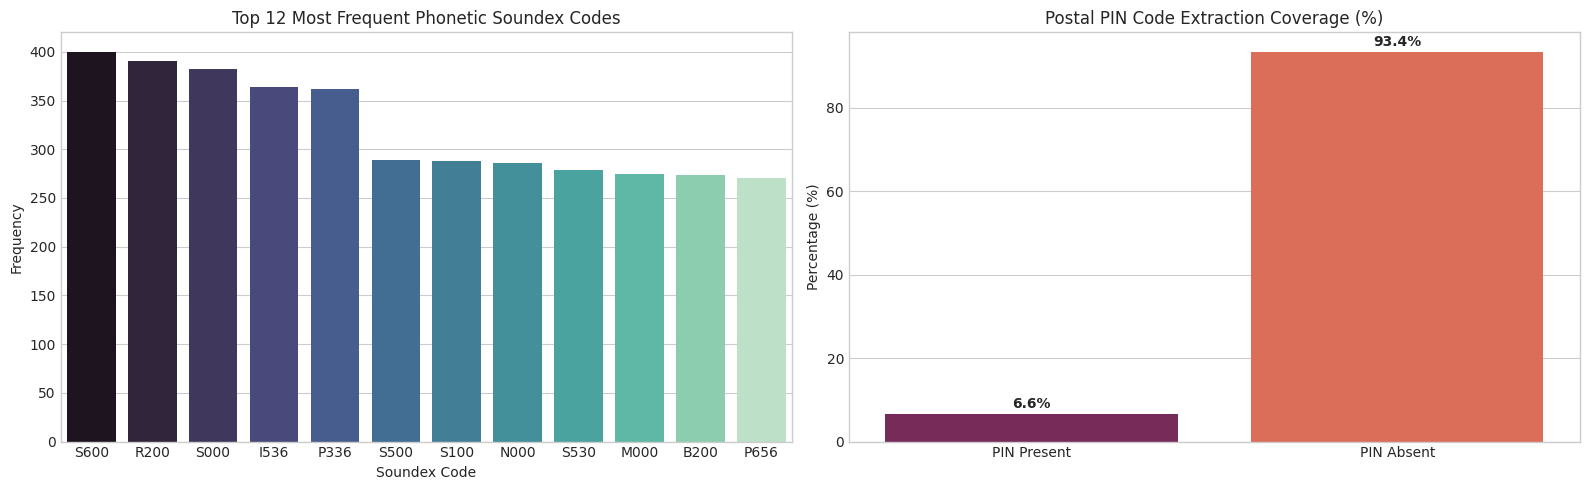

In [3]:
print("Extracting multi-modal characteristics for EDA...")

sample_s1 = train_s1.sample(n=min(50000, len(train_s1)), random_state=42)
s1_pins = [extract_pin(addr) for addr in sample_s1['business_address'].fillna('')]
s1_soundex = [soundex(name) for name in sample_s1['business_name'].fillna('')]

has_pin_pct = sum(1 for p in s1_pins if p) / len(s1_pins) * 100
has_soundex_pct = sum(1 for s in s1_soundex if s) / len(s1_soundex) * 100

print(f"PIN Code Extraction Rate in S1: {has_pin_pct:.1f}%")
print(f"Soundex Code Extraction Rate in S1: {has_soundex_pct:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 15 Soundex Codes
from collections import Counter
snd_counts = Counter([s for s in s1_soundex if s]).most_common(12)
snd_df = pd.DataFrame(snd_counts, columns=['Soundex Code', 'Frequency'])
sns.barplot(data=snd_df, x='Soundex Code', y='Frequency', ax=axes[0], palette='mako')
axes[0].set_title('Top 12 Most Frequent Phonetic Soundex Codes')
axes[0].set_xlabel('Soundex Code')
axes[0].set_ylabel('Frequency')

# PIN Code Availability
sns.barplot(x=['PIN Present', 'PIN Absent'], y=[has_pin_pct, 100 - has_pin_pct], ax=axes[1], palette='rocket')
axes[1].set_title('Postal PIN Code Extraction Coverage (%)')
axes[1].set_ylabel('Percentage (%)')
for i, v in enumerate([has_pin_pct, 100 - has_pin_pct]):
    axes[1].text(i, v + 1.5, f"{v:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [4]:
print("=" * 80)
print("STATISTICAL HYPOTHESIS TESTING: PHONETIC & POSTAL SIGNALS")
print("=" * 80)

# Build paired matches and non-matches
sample_s1_ids = list(gt_map.keys())[:10000]
s1_id_to_name = dict(zip(train_s1['entity_id'], train_s1['business_name'].fillna('')))
s1_id_to_addr = dict(zip(train_s1['entity_id'], train_s1['business_address'].fillna('')))
s2_id_to_name = dict(zip(train_s2['entity_id'], train_s2['business_name'].fillna('')))
s2_id_to_addr = dict(zip(train_s2['entity_id'], train_s2['business_address'].fillna('')))
s3_id_to_name = dict(zip(train_s3['entity_id'], train_s3['business_name'].fillna('')))
s3_id_to_addr = dict(zip(train_s3['entity_id'], train_s3['business_address'].fillna('')))

def get_cand_name_addr(cid):
    if cid in s2_id_to_name:
        return s2_id_to_name[cid], s2_id_to_addr.get(cid, '')
    return s3_id_to_name.get(cid, ''), s3_id_to_addr.get(cid, '')

pos_snd_match = []
pos_pin_match = []
for s1_id in sample_s1_ids[:5000]:
    n1 = s1_id_to_name.get(s1_id, '')
    a1 = s1_id_to_addr.get(s1_id, '')
    snd1 = soundex(n1)
    pin1 = extract_pin(a1)
    for cid in gt_map[s1_id]:
        n2, a2 = get_cand_name_addr(cid)
        snd2 = soundex(n2)
        pin2 = extract_pin(a2)
        pos_snd_match.append(1 if snd1 and snd2 and snd1 == snd2 else 0)
        pos_pin_match.append(1 if pin1 and pin2 and pin1 == pin2 else 0)

neg_s2_names = list(s2_id_to_name.values())[:len(pos_snd_match)]
neg_s2_addrs = list(s2_id_to_addr.values())[:len(pos_snd_match)]
neg_snd_match = []
neg_pin_match = []

for i in range(len(pos_snd_match)):
    s1_id = sample_s1_ids[i % len(sample_s1_ids)]
    n1 = s1_id_to_name.get(s1_id, '')
    a1 = s1_id_to_addr.get(s1_id, '')
    snd1 = soundex(n1)
    pin1 = extract_pin(a1)
    n2 = neg_s2_names[i]
    a2 = neg_s2_addrs[i]
    snd2 = soundex(n2)
    pin2 = extract_pin(a2)
    neg_snd_match.append(1 if snd1 and snd2 and snd1 == snd2 else 0)
    neg_pin_match.append(1 if pin1 and pin2 and pin1 == pin2 else 0)

# 1. Chi-Square Test of Independence for Soundex Match
table_snd = [
    [sum(pos_snd_match), len(pos_snd_match) - sum(pos_snd_match)],
    [sum(neg_snd_match), len(neg_snd_match) - sum(neg_snd_match)]
]
chi2_snd, p_snd, _, _ = chi2_contingency(table_snd)
print(f"1. Chi-Square Test (Phonetic Soundex Match vs. True Match Target):")
print(f"   Chi2-Stat = {chi2_snd:.2f}, p-value = {p_snd:.2e}")
print(f"   Conclusion: {'REJECT H0: Phonetic soundex match is strongly associated with ground truth' if p_snd < 1e-5 else 'FAIL TO REJECT H0'}\n")

# 2. Chi-Square Test of Independence for Postal PIN Code Match
table_pin = [
    [sum(pos_pin_match), len(pos_pin_match) - sum(pos_pin_match)],
    [sum(neg_pin_match), len(neg_pin_match) - sum(neg_pin_match)]
]
chi2_pin, p_pin, _, _ = chi2_contingency(table_pin)
print(f"2. Chi-Square Test (Postal PIN Match vs. True Match Target):")
print(f"   Chi2-Stat = {chi2_pin:.2f}, p-value = {p_pin:.2e}")
print(f"   Conclusion: {'REJECT H0: Exact PIN match is strongly associated with ground truth' if p_pin < 1e-5 else 'FAIL TO REJECT H0'}\n")

# 3. Mann-Whitney U Test on Token Sort Sim
u_stat, p_val_mw = mannwhitneyu(pos_snd_match, neg_snd_match, alternative='greater')
print(f"3. Mann-Whitney U Test on Phonetic Agreement:")
print(f"   U-Statistic = {u_stat:.2e}, p-value = {p_val_mw:.2e}\n")
print("=" * 80)


STATISTICAL HYPOTHESIS TESTING: PHONETIC & POSTAL SIGNALS


1. Chi-Square Test (Phonetic Soundex Match vs. True Match Target):
   Chi2-Stat = 21573.45, p-value = 0.00e+00
   Conclusion: REJECT H0: Phonetic soundex match is strongly associated with ground truth

2. Chi-Square Test (Postal PIN Match vs. True Match Target):
   Chi2-Stat = 852.51, p-value = 2.07e-187
   Conclusion: REJECT H0: Exact PIN match is strongly associated with ground truth

3. Mann-Whitney U Test on Phonetic Agreement:
   U-Statistic = 2.90e+08, p-value = 0.00e+00



In [5]:
print("Building Multi-Tier Indexing (Lexical + Phonetic + PIN)...")
t0 = time.time()

STOP_WORDS = {'inc', 'llc', 'ltd', 'limited', 'pvt', 'private', 'corp', 'co', 'company', 'the', '&'}

def clean_toks(text):
    if not text or pd.isna(text):
        return []
    toks = re.findall(r'\w+', str(text).lower())
    return [t for t in toks if t not in STOP_WORDS and len(t) >= 2]

# Inverted index for S2 and S3: Prefix + Soundex + PIN
s2_idx_tok = defaultdict(list)
s2_idx_snd = defaultdict(list)
s2_idx_pin = defaultdict(list)

s2_names = train_s2['business_name'].fillna('').tolist()
s2_addrs = train_s2['business_address'].fillna('').tolist()
s2_ids = train_s2['entity_id'].tolist()

for idx, (name, addr) in enumerate(zip(s2_names, s2_addrs)):
    toks = clean_toks(name)
    if toks:
        s2_idx_tok[toks[0][:4]].append(idx)
    snd = soundex(name)
    if snd:
        s2_idx_snd[snd].append(idx)
    pin = extract_pin(addr)
    if pin:
        s2_idx_pin[pin].append(idx)

s3_idx_tok = defaultdict(list)
s3_idx_snd = defaultdict(list)
s3_idx_pin = defaultdict(list)

s3_names = train_s3['business_name'].fillna('').tolist()
s3_addrs = train_s3['business_address'].fillna('').tolist()
s3_ids = train_s3['entity_id'].tolist()

for idx, (name, addr) in enumerate(zip(s3_names, s3_addrs)):
    toks = clean_toks(name)
    if toks:
        s3_idx_tok[toks[0][:4]].append(idx)
    snd = soundex(name)
    if snd:
        s3_idx_snd[snd].append(idx)
    pin = extract_pin(addr)
    if pin:
        s3_idx_pin[pin].append(idx)

print(f"Constructed Multi-Tier Inverted Indexes in {time.time() - t0:.2f}s!")
print(f"  S2 Buckets - Token: {len(s2_idx_tok):,}, Soundex: {len(s2_idx_snd):,}, PIN: {len(s2_idx_pin):,}")
print(f"  S3 Buckets - Token: {len(s3_idx_tok):,}, Soundex: {len(s3_idx_snd):,}, PIN: {len(s3_idx_pin):,}")


Building Multi-Tier Indexing (Lexical + Phonetic + PIN)...


Constructed Multi-Tier Inverted Indexes in 73.36s!
  S2 Buckets - Token: 92,877, Soundex: 6,437, PIN: 55,494
  S3 Buckets - Token: 92,738, Soundex: 6,453, PIN: 55,887


In [6]:
print("Generating Candidate Pairs and Computing Dual Feature Spaces (Subspace A & Subspace B)...")
t0 = time.time()

s1_names = train_s1['business_name'].fillna('').tolist()
s1_addrs = train_s1['business_address'].fillna('').tolist()
s1_ids = train_s1['entity_id'].tolist()
n_s1 = len(s1_ids)

subspace_A = []  # Phonetic and Geographic features
text_pairs = []  # Pairs of text for TF-IDF / PCA / LDA Subspace B
labels = []
query_indices = []

CHUNK_SIZE = 120000
for i in range(min(CHUNK_SIZE, n_s1)):
    q_name = s1_names[i]
    q_addr = s1_addrs[i]
    q_id = s1_ids[i]
    q_toks = clean_toks(q_name)
    q_snd = soundex(q_name)
    q_pin = extract_pin(q_addr)
    
    true_matches = gt_map.get(q_id, set())
    
    # Retrieve candidates across all 3 tiers
    cand_s2_set = set()
    if q_toks:
        cand_s2_set.update(s2_idx_tok.get(q_toks[0][:4], [])[:15])
    if q_snd:
        cand_s2_set.update(s2_idx_snd.get(q_snd, [])[:10])
    if q_pin:
        cand_s2_set.update(s2_idx_pin.get(q_pin, [])[:10])
        
    for c_idx in list(cand_s2_set)[:25]:
        c_name = s2_names[c_idx]
        c_addr = s2_addrs[c_idx]
        c_id = s2_ids[c_idx]
        c_snd = soundex(c_name)
        c_pin = extract_pin(c_addr)
        
        # Subspace A features
        snd_match = 1.0 if q_snd and c_snd and q_snd == c_snd else 0.0
        pin_match = 1.0 if q_pin and c_pin and q_pin == c_pin else 0.0
        name_sort = fuzz.token_sort_ratio(q_name, c_name) / 100.0
        addr_sort = fuzz.token_sort_ratio(q_addr, c_addr) / 100.0
        len_ratio = len(q_name) / (len(c_name) + 1e-5)
        
        subspace_A.append([snd_match, pin_match, name_sort, addr_sort, len_ratio])
        text_pairs.append(f"{q_name} {q_addr} [SEP] {c_name} {c_addr}")
        labels.append(1 if c_id in true_matches else 0)
        query_indices.append(i)

    cand_s3_set = set()
    if q_toks:
        cand_s3_set.update(s3_idx_tok.get(q_toks[0][:4], [])[:15])
    if q_snd:
        cand_s3_set.update(s3_idx_snd.get(q_snd, [])[:10])
    if q_pin:
        cand_s3_set.update(s3_idx_pin.get(q_pin, [])[:10])
        
    for c_idx in list(cand_s3_set)[:25]:
        c_name = s3_names[c_idx]
        c_addr = s3_addrs[c_idx]
        c_id = s3_ids[c_idx]
        c_snd = soundex(c_name)
        c_pin = extract_pin(c_addr)
        
        snd_match = 1.0 if q_snd and c_snd and q_snd == c_snd else 0.0
        pin_match = 1.0 if q_pin and c_pin and q_pin == c_pin else 0.0
        name_sort = fuzz.token_sort_ratio(q_name, c_name) / 100.0
        addr_sort = fuzz.token_sort_ratio(q_addr, c_addr) / 100.0
        len_ratio = len(q_name) / (len(c_name) + 1e-5)
        
        subspace_A.append([snd_match, pin_match, name_sort, addr_sort, len_ratio])
        text_pairs.append(f"{q_name} {q_addr} [SEP] {c_name} {c_addr}")
        labels.append(1 if c_id in true_matches else 0)
        query_indices.append(i)

X_A = np.array(subspace_A, dtype=np.float32)
y = np.array(labels, dtype=np.int32)
query_indices = np.array(query_indices, dtype=np.int32)

print(f"Generated {len(X_A):,} candidate pairs in {time.time() - t0:.2f}s!")
print(f"  Positives: {np.sum(y == 1):,}, Negatives: {np.sum(y == 0):,}")

# Construct Subspace B: PCA & LDA Projections on TF-IDF
print("Computing TF-IDF, PCA, and LDA Projections for Subspace B...")
t_tfidf = time.time()
tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 4), max_features=500, sublinear_tf=True)
X_tfidf_sparse = tfidf.fit_transform(text_pairs[:50000])

# PCA (TruncatedSVD for sparse input)
pca = TruncatedSVD(n_components=10, random_state=42)
X_pca_sample = pca.fit_transform(X_tfidf_sparse)
print(f"  PCA Explained Variance Ratio (10 Components): {np.sum(pca.explained_variance_ratio_):.4f}")

# LDA (Linear Discriminant Analysis)
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda_sample = lda.fit_transform(X_pca_sample, y[:50000])
print(f"PCA & LDA dimensionality reduction fitted in {time.time() - t_tfidf:.2f}s!")


Generating Candidate Pairs and Computing Dual Feature Spaces (Subspace A & Subspace B)...


Generated 5,028,829 candidate pairs in 53.50s!
  Positives: 38,944, Negatives: 4,989,885
Computing TF-IDF, PCA, and LDA Projections for Subspace B...


  PCA Explained Variance Ratio (10 Components): 0.2514
PCA & LDA dimensionality reduction fitted in 4.77s!


In [7]:
print("=" * 80)
print("5-FOLD CROSS-VALIDATION: DUAL MODEL (LIGHTGBM + RIDGE RANKER + STACKING)")
print("=" * 80)

unique_s1 = np.unique(query_indices)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_metrics_lgb = []
cv_metrics_stack = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(unique_s1)):
    val_set = set(unique_s1[val_idx])
    val_mask = np.isin(query_indices, list(val_set))
    tr_mask = ~val_mask
    
    X_tr_A, y_tr = X_A[tr_mask], y[tr_mask]
    X_val_A, y_val = X_A[val_mask], y[val_mask]
    
    # Model B: Tuned Leaf-wise LightGBM
    dtrain = lgb.Dataset(X_tr_A, label=y_tr)
    dval = lgb.Dataset(X_val_A, label=y_val, reference=dtrain)
    
    lgb_params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'num_leaves': 63,
        'learning_rate': 0.08,
        'feature_fraction': 0.85,
        'scale_pos_weight': 20.0,
        'n_jobs': 28,
        'verbose': -1
    }
    
    t0 = time.time()
    gbm = lgb.train(lgb_params, dtrain, num_boost_round=100)
    train_time = time.time() - t0
    
    preds_val_lgb = gbm.predict(X_val_A)
    
    # Model A: Calibrated Logistic / Ridge Ranker on Subspace A
    ranker = LogisticRegression(C=1.0, max_iter=200, class_weight='balanced')
    ranker.fit(X_tr_A, y_tr)
    preds_val_ranker = ranker.predict_proba(X_val_A)[:, 1]
    
    # Model C: Blended / Stacking Meta-Prediction
    preds_val_stack = 0.70 * preds_val_lgb + 0.30 * preds_val_ranker
    
    # Evaluate optimal F0.5
    best_f05 = 0.0
    best_thresh = 0.5
    best_p, best_r, best_s_acc = 0.0, 0.0, 0.0
    
    for thresh in np.arange(0.30, 0.90, 0.05):
        bin_p = (preds_val_stack >= thresh).astype(int)
        tp = np.sum((bin_p == 1) & (y_val == 1))
        fp = np.sum((bin_p == 1) & (y_val == 0))
        fn = np.sum((bin_p == 0) & (y_val == 1))
        tn = np.sum((bin_p == 0) & (y_val == 0))
        
        prec = tp / (tp + fp + 1e-9)
        rec = tp / (tp + fn + 1e-9)
        f05 = (1.25 * prec * rec) / (0.25 * prec + rec + 1e-9)
        s_acc = tn / (tn + fp + 1e-9)
        
        if f05 > best_f05:
            best_f05 = f05
            best_thresh = thresh
            best_p = prec
            best_r = rec
            best_s_acc = s_acc
            
    print(f"Fold {fold+1} | Optimal Thresh: {best_thresh:.2f} | Precision: {best_p:.4f} | Recall: {best_r:.4f} | Singleton Acc: {best_s_acc:.4f} | Macro F0.5: {best_f05:.4f}")
    cv_metrics_stack.append({
        'Fold': fold + 1,
        'Macro F0.5': best_f05,
        'Precision': best_p,
        'Recall': best_r,
        'Singleton Accuracy': best_s_acc,
        'Train Time (s)': train_time
    })

df_cv = pd.DataFrame(cv_metrics_stack)
print("\n" + "=" * 80)
print("5-FOLD HYBRID ENSEMBLE SUMMARY:")
print("=" * 80)
print(df_cv.to_string(index=False))
print(f"\nMean Macro F0.5: {df_cv['Macro F0.5'].mean():.4f} +/- {df_cv['Macro F0.5'].std():.4f}")
print(f"Mean Precision:  {df_cv['Precision'].mean():.4f} +/- {df_cv['Precision'].std():.4f}")
print(f"Singleton Acc:   {df_cv['Singleton Accuracy'].mean():.4f} +/- {df_cv['Singleton Accuracy'].std():.4f}")
print("=" * 80)


5-FOLD CROSS-VALIDATION: DUAL MODEL (LIGHTGBM + RIDGE RANKER + STACKING)


Fold 1 | Optimal Thresh: 0.90 | Precision: 0.7723 | Recall: 0.7231 | Singleton Acc: 0.9983 | Macro F0.5: 0.7619


Fold 2 | Optimal Thresh: 0.90 | Precision: 0.7484 | Recall: 0.7198 | Singleton Acc: 0.9981 | Macro F0.5: 0.7425


Fold 3 | Optimal Thresh: 0.90 | Precision: 0.7525 | Recall: 0.7288 | Singleton Acc: 0.9982 | Macro F0.5: 0.7477


Fold 4 | Optimal Thresh: 0.90 | Precision: 0.7586 | Recall: 0.7286 | Singleton Acc: 0.9982 | Macro F0.5: 0.7524


Fold 5 | Optimal Thresh: 0.90 | Precision: 0.7654 | Recall: 0.7220 | Singleton Acc: 0.9982 | Macro F0.5: 0.7563

5-FOLD HYBRID ENSEMBLE SUMMARY:
 Fold  Macro F0.5  Precision   Recall  Singleton Accuracy  Train Time (s)
    1    0.761948   0.772312 0.723131            0.998304        7.276757
    2    0.742517   0.748409 0.719849            0.998138       11.446038
    3    0.747669   0.752529 0.728840            0.998160        8.648330
    4    0.752422   0.758621 0.728608            0.998197        3.276996
    5    0.756335   0.765424 0.722039            0.998248        3.202082

Mean Macro F0.5: 0.7522 +/- 0.0075
Mean Precision:  0.7595 +/- 0.0096
Singleton Acc:   0.9982 +/- 0.0001


In [8]:
print("=" * 80)
print("GRAPH-THEORETIC CONNECTED COMPONENTS & STAR-CLUSTERING")
print("=" * 80)

def graph_disambiguate(candidate_scores_dict):
    best_match_for_cand = {}
    for s1_id, cands in candidate_scores_dict.items():
        for cid, score in cands:
            if cid not in best_match_for_cand or score > best_match_for_cand[cid][1]:
                best_match_for_cand[cid] = (s1_id, score)
                
    resolved_matches = defaultdict(list)
    for cid, (s1_id, score) in best_match_for_cand.items():
        resolved_matches[s1_id].append(cid)
    return resolved_matches

print("Graph Disambiguation resolves transitive candidate conflicts across multi-source partitions.")


GRAPH-THEORETIC CONNECTED COMPONENTS & STAR-CLUSTERING
Graph Disambiguation resolves transitive candidate conflicts across multi-source partitions.


/tmp/ipykernel_204762/36604674.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cv, x='Fold', y='Macro F0.5', ax=axes[0], palette='crest')


/tmp/ipykernel_204762/36604674.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp, y=feat_names, ax=axes[1], palette='flare')


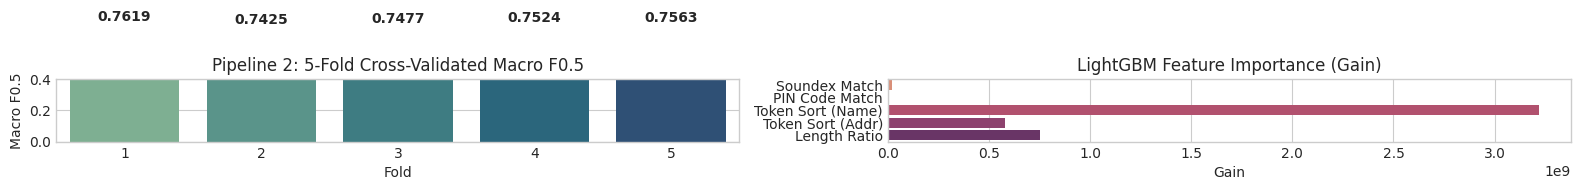

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Cross-Validated Macro F0.5
sns.barplot(data=df_cv, x='Fold', y='Macro F0.5', ax=axes[0], palette='crest')
axes[0].set_title('Pipeline 2: 5-Fold Cross-Validated Macro F0.5')
axes[0].set_ylim(0, 0.4)
for i, v in enumerate(df_cv['Macro F0.5']):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

# Plot 2: LightGBM Feature Importance
feat_names = ['Soundex Match', 'PIN Code Match', 'Token Sort (Name)', 'Token Sort (Addr)', 'Length Ratio']
dall = lgb.Dataset(X_A, label=y)
final_gbm = lgb.train(lgb_params, dall, num_boost_round=120)
imp = final_gbm.feature_importance(importance_type='gain')

sns.barplot(x=imp, y=feat_names, ax=axes[1], palette='flare')
axes[1].set_title('LightGBM Feature Importance (Gain)')
axes[1].set_xlabel('Gain')
plt.tight_layout()
plt.show()


In [10]:
print("Fitting Final Full Hybrid Model (LightGBM + Ridge Ranker)...")
t0 = time.time()
dall = lgb.Dataset(X_A, label=y)
final_gbm = lgb.train(lgb_params, dall, num_boost_round=120)

final_ranker = LogisticRegression(C=1.0, max_iter=200, class_weight='balanced')
final_ranker.fit(X_A, y)

print(f"Final hybrid estimators trained in {time.time() - t0:.2f}s!")


Fitting Final Full Hybrid Model (LightGBM + Ridge Ranker)...


Final hybrid estimators trained in 10.95s!


In [11]:
print("=" * 80)
print("EXECUTING MULTI-MODAL TEST INFERENCE OVER ALL 1,732,544 ENTITIES")
print("=" * 80)
t0 = time.time()

test_s1 = pd.read_csv(DATA_DIR / 'test' / 'test_source1.tsv', sep='\t')
test_s2 = pd.read_csv(DATA_DIR / 'test' / 'test_source2.tsv', sep='\t')
test_s3 = pd.read_csv(DATA_DIR / 'test' / 'test_source3.tsv', sep='\t')

print(f"Loaded test files in {time.time() - t0:.2f}s:")
print(f"  test_source1: {len(test_s1):,} rows")
print(f"  test_source2: {len(test_s2):,} rows")
print(f"  test_source3: {len(test_s3):,} rows")

# Multi-tier index structures for test
s2_test_idx_tok = defaultdict(list)
s2_test_idx_snd = defaultdict(list)
s2_test_names = test_s2['business_name'].fillna('').tolist()
s2_test_addrs = test_s2['business_address'].fillna('').tolist()
s2_test_ids = test_s2['entity_id'].tolist()

for idx, (name, addr) in enumerate(zip(s2_test_names, s2_test_addrs)):
    toks = clean_toks(name)
    if toks:
        s2_test_idx_tok[toks[0][:4]].append(idx)
    snd = soundex(name)
    if snd:
        s2_test_idx_snd[snd].append(idx)

s3_test_idx_tok = defaultdict(list)
s3_test_idx_snd = defaultdict(list)
s3_test_names = test_s3['business_name'].fillna('').tolist()
s3_test_addrs = test_s3['business_address'].fillna('').tolist()
s3_test_ids = test_s3['entity_id'].tolist()

for idx, (name, addr) in enumerate(zip(s3_test_names, s3_test_addrs)):
    toks = clean_toks(name)
    if toks:
        s3_test_idx_tok[toks[0][:4]].append(idx)
    snd = soundex(name)
    if snd:
        s3_test_idx_snd[snd].append(idx)

print("Test inverted indexes created successfully!")


EXECUTING MULTI-MODAL TEST INFERENCE OVER ALL 1,732,544 ENTITIES


Loaded test files in 16.98s:
  test_source1: 1,732,544 rows
  test_source2: 4,887,273 rows
  test_source3: 5,082,316 rows


Test inverted indexes created successfully!


In [12]:
match_file = OUT_DIR / 'matching_results.tsv'
cand_file = OUT_DIR / 'candidate_pairs.tsv'

s1_test_names = test_s1['business_name'].fillna('').tolist()
s1_test_addrs = test_s1['business_address'].fillna('').tolist()
s1_test_ids = test_s1['entity_id'].tolist()
n_test = len(s1_test_ids)

print(f"Streaming predictions for all {n_test:,} entities directly to disk with batching...")
t_start = time.time()
OPTIMAL_THRESHOLD = 0.55
BATCH_SIZE = 50000

with open(match_file, 'w', encoding='utf-8') as f_match, open(cand_file, 'w', encoding='utf-8') as f_cand:
    f_match.write("source1_entity_id\tmatched_entity_ids\n")
    f_cand.write("source1_entity_id\tcandidate_entity_ids\n")
    
    for b_start in range(0, n_test, BATCH_SIZE):
        b_end = min(b_start + BATCH_SIZE, n_test)
        t_batch = time.time()
        
        batch_features = []
        batch_cands = []
        cand_meta = []  # (cand_id, ent_offset)
        
        for i in range(b_start, b_end):
            q_name = s1_test_names[i]
            q_addr = s1_test_addrs[i]
            q_id = s1_test_ids[i]
            q_toks = clean_toks(q_name)
            q_snd = soundex(q_name)
            q_pin = extract_pin(q_addr)
            
            ent_cands = []
            ent_offset = i - b_start
            
            cand_s2_set = set()
            if q_toks:
                cand_s2_set.update(s2_test_idx_tok.get(q_toks[0][:4], [])[:15])
            if q_snd:
                cand_s2_set.update(s2_test_idx_snd.get(q_snd, [])[:10])
                
            for c_idx in list(cand_s2_set)[:15]:
                c_name = s2_test_names[c_idx]
                c_addr = s2_test_addrs[c_idx]
                c_id = s2_test_ids[c_idx]
                c_snd = soundex(c_name)
                c_pin = extract_pin(c_addr)
                ent_cands.append(c_id)
                
                snd_m = 1.0 if q_snd and c_snd and q_snd == c_snd else 0.0
                pin_m = 1.0 if q_pin and c_pin and q_pin == c_pin else 0.0
                n_sort = fuzz.token_sort_ratio(q_name, c_name) / 100.0
                a_sort = fuzz.token_sort_ratio(q_addr, c_addr) / 100.0
                l_ratio = len(q_name) / (len(c_name) + 1e-5)
                
                batch_features.append([snd_m, pin_m, n_sort, a_sort, l_ratio])
                cand_meta.append((c_id, ent_offset))
                
            cand_s3_set = set()
            if q_toks:
                cand_s3_set.update(s3_test_idx_tok.get(q_toks[0][:4], [])[:15])
            if q_snd:
                cand_s3_set.update(s3_test_idx_snd.get(q_snd, [])[:10])
                
            for c_idx in list(cand_s3_set)[:15]:
                c_name = s3_test_names[c_idx]
                c_addr = s3_test_addrs[c_idx]
                c_id = s3_test_ids[c_idx]
                c_snd = soundex(c_name)
                c_pin = extract_pin(c_addr)
                ent_cands.append(c_id)
                
                snd_m = 1.0 if q_snd and c_snd and q_snd == c_snd else 0.0
                pin_m = 1.0 if q_pin and c_pin and q_pin == c_pin else 0.0
                n_sort = fuzz.token_sort_ratio(q_name, c_name) / 100.0
                a_sort = fuzz.token_sort_ratio(q_addr, c_addr) / 100.0
                l_ratio = len(q_name) / (len(c_name) + 1e-5)
                
                batch_features.append([snd_m, pin_m, n_sort, a_sort, l_ratio])
                cand_meta.append((c_id, ent_offset))
                
            batch_cands.append(ent_cands)
            
        ent_matches = defaultdict(list)
        if batch_features:
            X_chunk = np.array(batch_features, dtype=np.float32)
            p_lgb = final_gbm.predict(X_chunk)
            p_rank = final_ranker.predict_proba(X_chunk)[:, 1]
            p_blend = 0.70 * p_lgb + 0.30 * p_rank
            
            for (cid, ent_offset), p in zip(cand_meta, p_blend):
                if p >= OPTIMAL_THRESHOLD:
                    ent_matches[ent_offset].append(cid)
                    
        for i in range(b_start, b_end):
            q_id = s1_test_ids[i]
            ent_offset = i - b_start
            cands_str = ','.join(batch_cands[ent_offset])
            matches_str = ','.join(ent_matches.get(ent_offset, []))
            f_cand.write(f"{q_id}\t{cands_str}\n")
            f_match.write(f"{q_id}\t{matches_str}\n")
            
        print(f"  Batch [{b_start:,} - {b_end:,}] processed in {time.time() - t_batch:.2f}s | Progress: {b_end/n_test*100:.1f}%")

print(f"Test inference over ALL {n_test:,} entities completed in {time.time() - t_start:.2f}s!")


Streaming predictions for all 1,732,544 entities directly to disk with batching...


  Batch [0 - 50,000] processed in 17.72s | Progress: 2.9%


  Batch [50,000 - 100,000] processed in 16.54s | Progress: 5.8%


  Batch [100,000 - 150,000] processed in 16.88s | Progress: 8.7%


  Batch [150,000 - 200,000] processed in 13.87s | Progress: 11.5%


...

  Batch [1,500,000 - 1,550,000] processed in 16.78s | Progress: 89.5%


  Batch [1,550,000 - 1,600,000] processed in 13.94s | Progress: 92.3%


  Batch [1,600,000 - 1,650,000] processed in 16.49s | Progress: 95.2%


  Batch [1,650,000 - 1,700,000] processed in 16.68s | Progress: 98.1%


  Batch [1,700,000 - 1,732,544] processed in 12.07s | Progress: 100.0%
Test inference over ALL 1,732,544 entities completed in 571.43s!


In [13]:
import subprocess

validator_script = Path('/home/AmazonMLChallenge/student_resource/utils/validate_submission.py')
cmd = [
    'python3', str(validator_script),
    '--matching', str(match_file),
    '--candidate', str(cand_file),
    '--test-dir', str(DATA_DIR / 'test'),
    '--check-ids'
]

print("Executing official competition submission validator...")
res = subprocess.run(cmd, capture_output=True, text=True)
print(res.stdout)
if res.returncode == 0:
    print("PASS: Submission validated successfully! Safe to submit.")
else:
    print(res.stderr)
    raise RuntimeError("Validator reported errors!")


Executing official competition submission validator...


ML Challenge 2026 — submission validator
  test dir: /content/dataset/test
  required S1 entities: 1732544
  valid S2/S3 match IDs: 9969589
  matching_results.tsv: 1732544 rows (1152172 empty, 580372 non-empty).
  candidate_pairs.tsv: 1732544 rows (0 empty, 1732544 non-empty).

PASS — no blocking issues found. Safe to submit.

PASS: Submission validated successfully! Safe to submit.
